# La letra pequeña de los PC con IA
## EDA sobre la inteligencia híbrida de Microsoft

Microsoft presentó el 7 de octubre de 2026 Surface Laptop Ultra, RTX Spark Dev Box y una nueva visión de Windows centrada en modelos locales y agentes. Este análisis no intenta predecir ventas ni entrenar un modelo con una muestra insuficiente. Realiza un **análisis exploratorio de datos** para responder una pregunta editorial:

> **Cuando la industria dice que los “PC con IA” están a punto de ser mayoría, ¿habla de ordenadores capaces de ejecutar la inteligencia híbrida que Microsoft acaba de presentar?**

**Consulta documental: 8 de octubre de 2026.** Los datos quedan guardados en CSV para que el cuaderno se ejecute sin internet.

## 1. Preparación del análisis

El cuaderno sigue la estructura habitual de Nebula: datos locales, controles, una pregunta por bloque, gráfico, lectura editorial, limitaciones y fuentes. No contiene una predicción ni se presenta como machine learning.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

BASE = Path.cwd()
if not (BASE / "datos_prevision_ai_pc.csv").exists():
    BASE = Path(r"C:\Users\rober\OneDrive\Documentos\proyectos_datos\_repos_nebula\microsoft_inteligencia_hibrida")

GRAFICOS = BASE / "graficos"
RESULTADOS = BASE / "resultados"
GRAFICOS.mkdir(exist_ok=True)
RESULTADOS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120
})
MORADO, AZUL, VERDE, GRIS, ROJO = "#7655B5", "#243F67", "#2A9D8F", "#8C93A4", "#C8553D"
pd.set_option("display.max_colwidth", 80)

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(GRAFICOS / nombre, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

## 2. Carga y control

Se separan tres tipos de material:

- Estimaciones y previsiones de consultoras.
- Señales observadas en mercados o canales concretos.
- Especificaciones y precios anunciados por Microsoft.

No se mezclan como si fueran una sola serie temporal.

In [2]:
previsiones = pd.read_csv(
    BASE / "datos_prevision_ai_pc.csv",
    parse_dates=["fecha_publicacion"]
)
senales = pd.read_csv(
    BASE / "senales_mercado.csv",
    parse_dates=["fecha"]
)
fuentes = pd.read_csv(
    BASE / "fuentes.csv",
    parse_dates=["fecha"]
)

assert previsiones["id"].is_unique
assert senales["id"].is_unique
assert fuentes["id"].is_unique
assert previsiones["cuota_pct"].between(0, 100).all()
assert senales["fuente_id"].isin(fuentes["id"]).all()

print("Previsiones y estimaciones:", len(previsiones))
print("Señales de mercado y producto:", len(senales))
print("Fuentes documentadas:", len(fuentes))
display(previsiones[[
    "organizacion", "fecha_publicacion", "anio_objetivo",
    "cuota_pct", "tipo", "ambito", "uso"
]])

Previsiones y estimaciones: 10
Señales de mercado y producto: 8
Fuentes documentadas: 11


,organizacion,fecha_publicacion,anio_objetivo,cuota_pct,tipo,ambito,uso
0,Canalys/Omdia,2025-03-03,2024,17.0,estimacion_cierre,Global,base
1,Gartner,2024-09-25,2025,43.0,prevision_antigua,Global,revision
2,Gartner,2025-08-28,2025,31.0,estimacion_actualizada,Global,revision
3,Gartner,2025-08-28,2026,55.0,prevision_superada,Global,revision
4,Gartner,2025-12-17,2026,49.0,prevision,Global,modelo
5,Canalys/Omdia,NaT,2027,60.0,prevision,Global,modelo
6,Morgan Stanley Research,2024-05-21,2028,64.0,prevision,Global,modelo
7,IDC,NaT,2028,93.0,prevision,Global,modelo
8,Gartner,NaT,2029,96.0,prevision,Global,modelo
9,Omdia,2026-09-09,2026,48.3,observacion_regional,Estados Unidos,contraste


## 3. Primero: “AI PC” no significa lo mismo en todas partes

Canalys/Omdia utiliza una definición amplia: un PC con un chipset o bloque dedicado para ejecutar cargas de IA en el dispositivo. Gartner, IDC y Morgan Stanley aplican taxonomías propias.

La categoría no exige necesariamente 40 TOPS, 128 GB de memoria unificada ni capacidad para ejecutar un modelo de 120.000 millones de parámetros. Por tanto, las previsiones describen principalmente la **incorporación de hardware**, no la potencia mostrada por Microsoft.

,organizacion,definicion,registros
0,Canalys/Omdia,PC con chipset o bloque dedicado para cargas de IA en el dispositivo,2
1,Gartner,AI PC según la taxonomía de Gartner,2
2,IDC,AI PC según la taxonomía de IDC,1
3,Morgan Stanley Research,PC equipado para IA; definición del informe de inversión,1


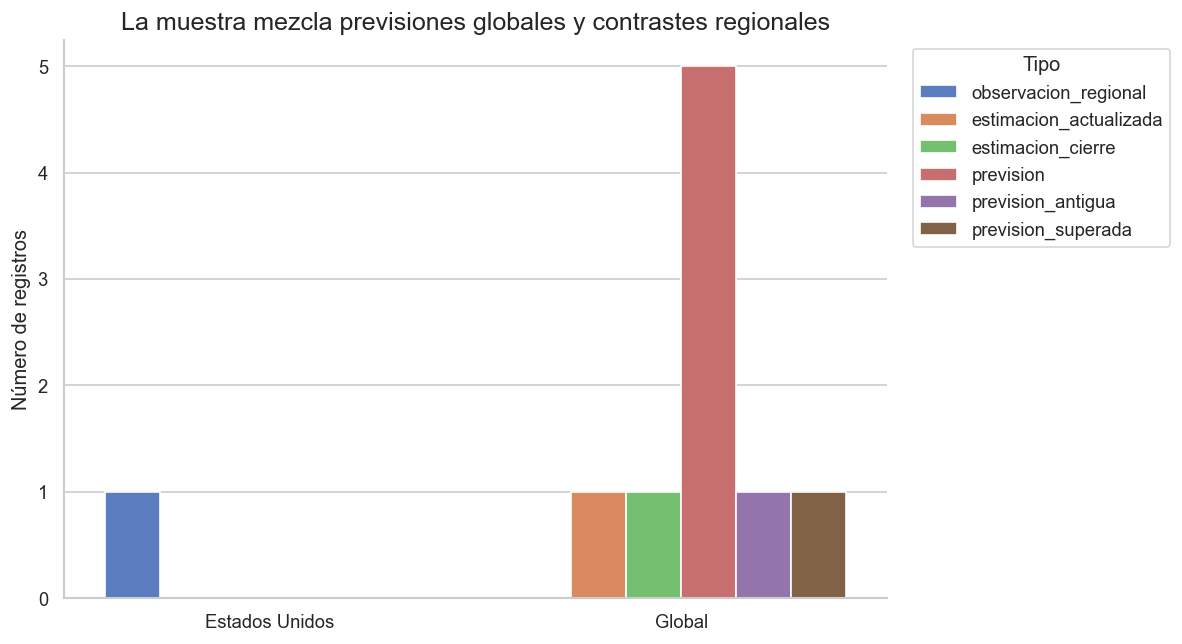

In [3]:
definiciones = (
    previsiones.loc[previsiones["uso"].isin(["base", "modelo"])]
    .groupby(["organizacion", "definicion"], as_index=False)
    .agg(registros=("id", "count"))
    .sort_values(["organizacion", "registros"], ascending=[True, False])
)
display(definiciones)

cobertura = (
    previsiones.groupby(["ambito", "tipo"], as_index=False)
    .agg(registros=("id", "count"))
)

plt.figure(figsize=(10, 5.5))
sns.barplot(data=cobertura, x="ambito", y="registros", hue="tipo", palette="muted")
plt.title("La muestra mezcla previsiones globales y contrastes regionales", fontsize=15)
plt.xlabel("")
plt.ylabel("Número de registros")
plt.legend(title="Tipo", bbox_to_anchor=(1.02, 1), loc="upper left")
guardar("01_eda_cobertura_fuentes.png")

### Lectura Nebula

La palabra “IA” agrupa niveles de capacidad demasiado distintos. Un portátil puede contabilizarse como AI PC por incorporar una NPU y, aun así, quedar muy lejos de los flujos locales que Microsoft utiliza para justificar sus nuevos equipos. El tamaño futuro de la categoría no mide automáticamente la utilidad futura de Copilot o de los agentes.

## 4. El hardware crece, pero las cifras comparables son escasas

Las estimaciones mundiales disponibles sitúan la cuota anual en el 17 % durante 2024 y en el 31 % durante 2025. Omdia observó un 48,3 % en Estados Unidos durante el segundo trimestre de 2026, pero ese dato no puede utilizarse como continuación directa de la serie mundial.

,id,fecha,region,valor,segmento,nota
0,ai_pc_global_2024,2024-12-31,Global,17.0,Todos los PC,Estimación anual con definición amplia de hardware dedicado
1,ai_pc_global_2025,2025-12-31,Global,31.0,Todos los PC,Estimación de cierre publicada en agosto de 2025
3,ai_pc_usa_q2_2026,2026-06-30,Estados Unidos,48.3,Todos los PC,Dato regional; no representa el total mundial


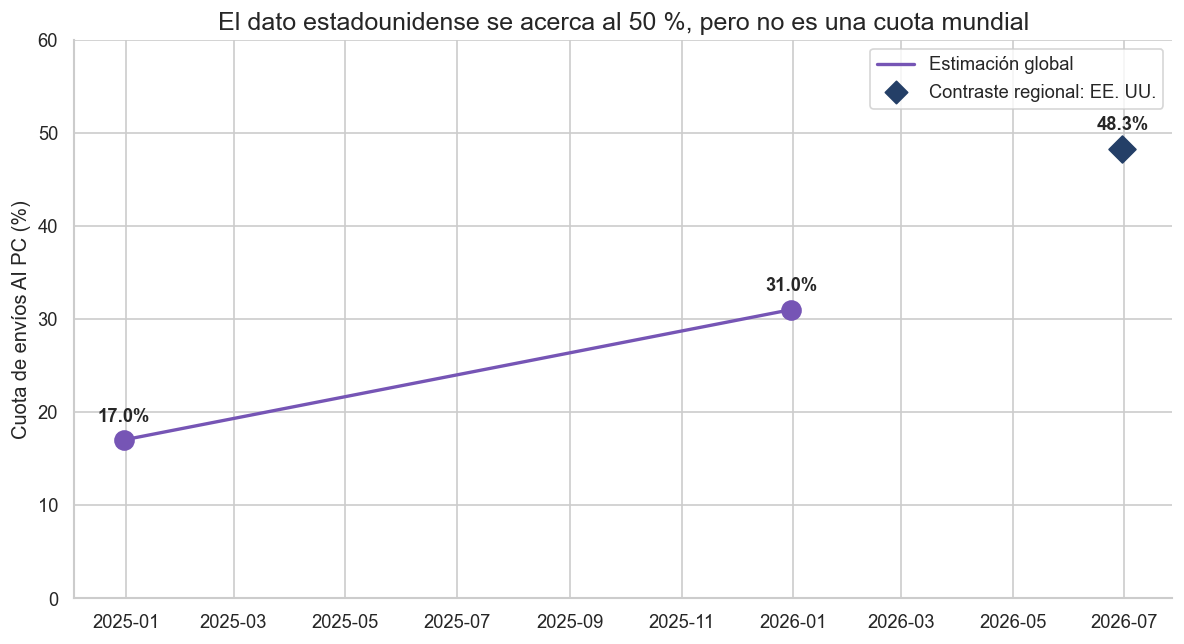

In [4]:
cuotas = senales.loc[
    senales["metrica"].eq("cuota_ai_pc"),
    ["id", "fecha", "region", "valor", "segmento", "nota"]
].sort_values("fecha")

display(cuotas)

fig, ax = plt.subplots(figsize=(10, 5.5))
for _, fila in cuotas.iterrows():
    color = MORADO if fila["region"] == "Global" else AZUL
    marcador = "o" if fila["region"] == "Global" else "D"
    ax.scatter(fila["fecha"], fila["valor"], s=130, color=color, marker=marcador)
    ax.text(fila["fecha"], fila["valor"] + 2, f"{fila['valor']:.1f}%", ha="center", fontweight="bold")

ax.plot(
    cuotas.loc[cuotas["region"].eq("Global"), "fecha"],
    cuotas.loc[cuotas["region"].eq("Global"), "valor"],
    color=MORADO, linewidth=2, label="Estimación global"
)
ax.scatter([], [], s=90, color=AZUL, marker="D", label="Contraste regional: EE. UU.")
ax.set_title("El dato estadounidense se acerca al 50 %, pero no es una cuota mundial", fontsize=15)
ax.set_ylabel("Cuota de envíos AI PC (%)")
ax.set_xlabel("")
ax.set_ylim(0, 60)
ax.legend()
guardar("02_eda_cuotas_observadas.png")

### Lectura Nebula

La dirección es clara: cada vez se venden más equipos con hardware dedicado para IA. La velocidad mundial de esa transición no puede reconstruirse con rigor a partir de tres puntos que emplean fuentes, periodos y geografías diferentes. Este es precisamente el motivo por el que el proyecto es un EDA y no un modelo de machine learning.

## 5. Las consultoras coinciden en la dirección, no en la velocidad

Las previsiones públicas oscilan desde el 49 % de Gartner para 2026 hasta el 93 % de IDC en 2028 y el 96 % de Gartner en 2029. Se representan como pronósticos publicados, no como observaciones ni como datos para entrenar un algoritmo.

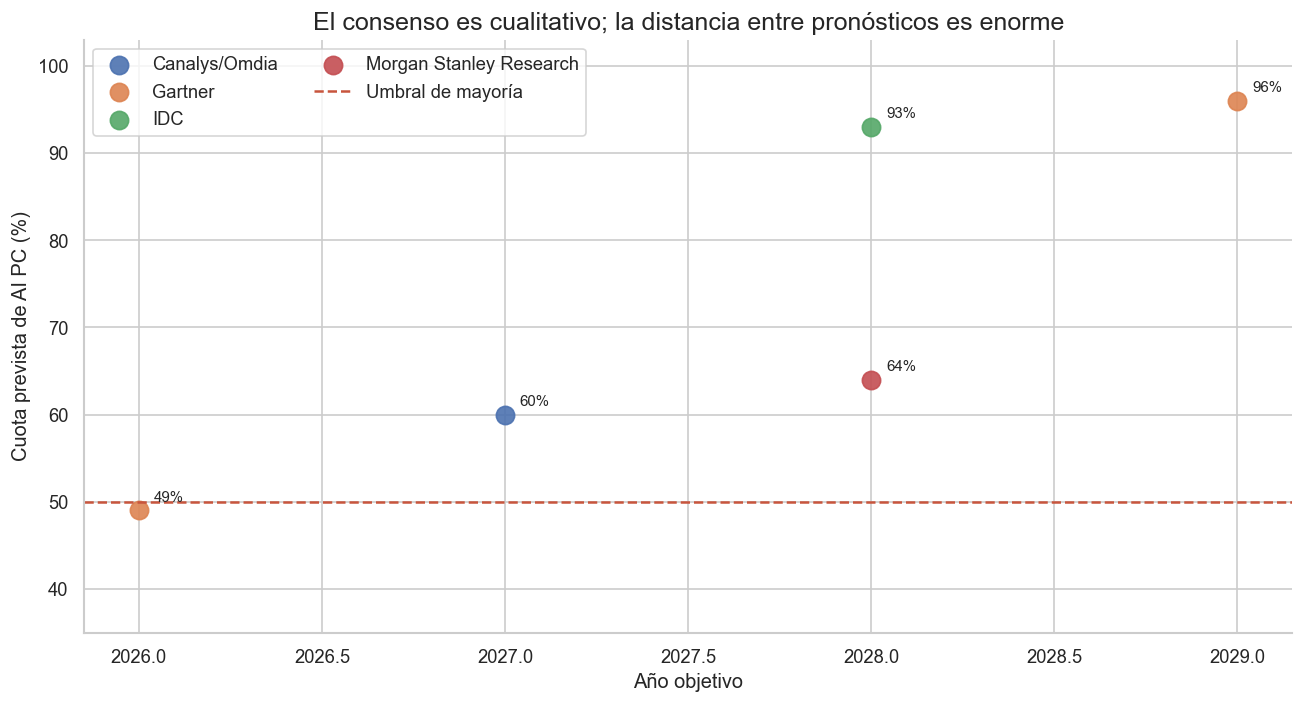

,anio_objetivo,previsiones,minimo_pct,maximo_pct,rango_pp
0,2026,1,49.0,49.0,0.0
1,2027,1,60.0,60.0,0.0
2,2028,2,64.0,93.0,29.0
3,2029,1,96.0,96.0,0.0


In [5]:
pronosticos = previsiones.loc[previsiones["uso"].eq("modelo")].copy()

plt.figure(figsize=(11, 6))
for organizacion, bloque in pronosticos.groupby("organizacion"):
    plt.scatter(
        bloque["anio_objetivo"], bloque["cuota_pct"],
        s=120, alpha=.9, label=organizacion
    )
    for _, fila in bloque.iterrows():
        plt.text(
            fila["anio_objetivo"] + .04,
            fila["cuota_pct"] + 1,
            f"{fila['cuota_pct']:.0f}%",
            fontsize=9
        )

plt.axhline(50, color=ROJO, linestyle="--", linewidth=1.5, label="Umbral de mayoría")
plt.title("El consenso es cualitativo; la distancia entre pronósticos es enorme", fontsize=15)
plt.ylabel("Cuota prevista de AI PC (%)")
plt.xlabel("Año objetivo")
plt.ylim(35, 103)
plt.legend(ncol=2)
guardar("03_eda_previsiones_publicadas.png")

dispersion = (
    pronosticos.groupby("anio_objetivo", as_index=False)
    .agg(
        previsiones=("id", "count"),
        minimo_pct=("cuota_pct", "min"),
        maximo_pct=("cuota_pct", "max"),
        rango_pp=("cuota_pct", lambda s: s.max() - s.min())
    )
)
display(dispersion)

### Lectura Nebula

En 2028, las proyecciones públicas recogidas van del 64 % al 93 %: **29 puntos de diferencia**. Esa brecha es más informativa que una media. Las consultoras comparten la expectativa de que el hardware se generalizará, pero no existe acuerdo sobre la rapidez ni una definición única del producto.

## 6. Las propias previsiones se corrigen a la baja

Gartner esperaba inicialmente que los AI PC representaran el 43 % del mercado en 2025; después situó la cifra en el 31 %. Para 2026 pasó del 55 % al 49 %. La revisión demuestra que las cifras de adopción no son destinos inevitables.

version,anio_objetivo,Actualizada,Inicial,revision_pp
0,2025,31.0,43.0,-12.0
1,2026,49.0,55.0,-6.0


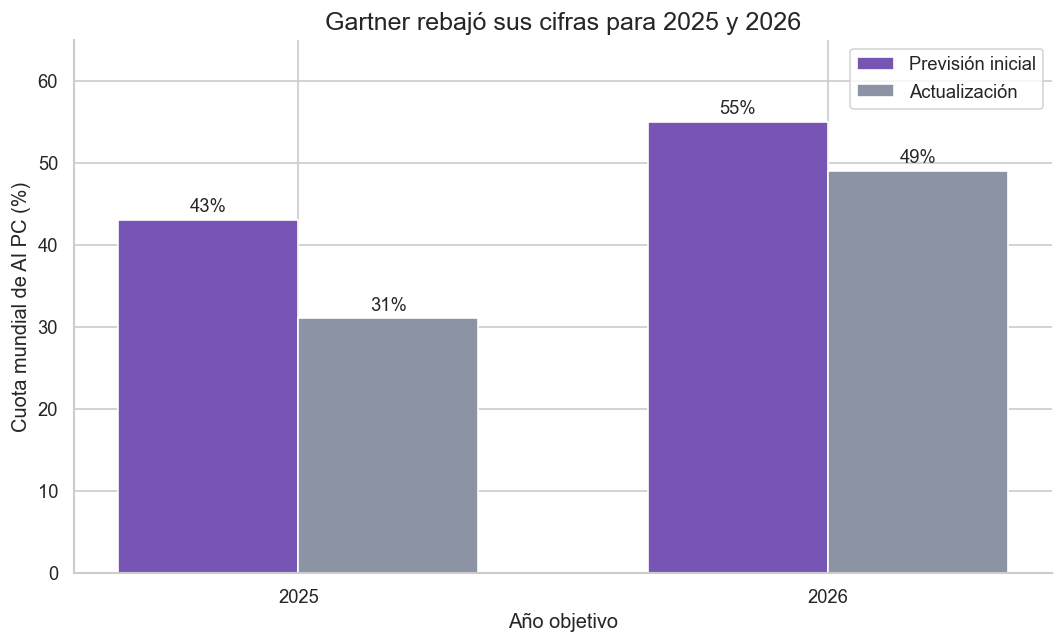

In [6]:
revisiones = previsiones.loc[
    previsiones["id"].isin([
        "gartner_prevision_2025_antigua",
        "gartner_estimacion_2025",
        "gartner_2026_inicial",
        "gartner_2026_revisada"
    ])
].copy()

revisiones["version"] = np.where(
    revisiones["tipo"].isin(["prevision_antigua", "prevision_superada"]),
    "Inicial",
    "Actualizada"
)

pivote = revisiones.pivot(
    index="anio_objetivo",
    columns="version",
    values="cuota_pct"
).reset_index()
pivote["revision_pp"] = pivote["Actualizada"] - pivote["Inicial"]
display(pivote)

x = np.arange(len(pivote))
ancho = .34
plt.figure(figsize=(9, 5.5))
plt.bar(x - ancho/2, pivote["Inicial"], width=ancho, color=MORADO, label="Previsión inicial")
plt.bar(x + ancho/2, pivote["Actualizada"], width=ancho, color=GRIS, label="Actualización")
for i, fila in pivote.iterrows():
    plt.text(i - ancho/2, fila["Inicial"] + 1, f"{fila['Inicial']:.0f}%", ha="center")
    plt.text(i + ancho/2, fila["Actualizada"] + 1, f"{fila['Actualizada']:.0f}%", ha="center")
plt.xticks(x, pivote["anio_objetivo"].astype(int))
plt.title("Gartner rebajó sus cifras para 2025 y 2026", fontsize=15)
plt.ylabel("Cuota mundial de AI PC (%)")
plt.xlabel("Año objetivo")
plt.ylim(0, 65)
plt.legend()
guardar("04_eda_revisiones_gartner.png")

### Lectura Nebula

La corrección de 2025 fue de **−12 puntos porcentuales** y la de 2026, de **−6 puntos**. El artículo puede afirmar que el hardware está avanzando, pero no debería convertir el calendario más optimista en una predicción propia de Nebula.

## 7. El salto entre AI PC y Copilot+ PC

CONTEXT calculó que solo el 9 % de los 1,2 millones de AI PC distribuidos profesionalmente en Europa durante el segundo trimestre de 2025 cumplía la especificación Copilot+ de 40 TOPS. El dato no representa el mercado mundial, pero ilustra cuánto se estrecha la categoría cuando se exige una capacidad concreta.

,categoria,porcentaje
0,Cumplían Copilot+,9.0
1,Otros AI PC distribuidos,91.0


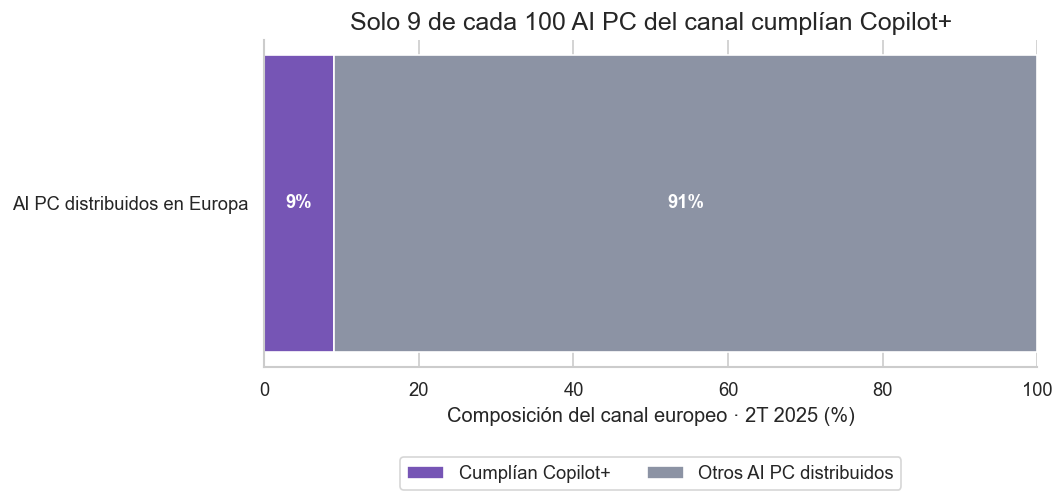

In [7]:
copilot = senales.loc[senales["id"].eq("copilot_europa_q2_2025")].iloc[0]
copilot_pct = float(copilot["valor"])

composicion = pd.DataFrame({
    "categoria": ["Cumplían Copilot+", "Otros AI PC distribuidos"],
    "porcentaje": [copilot_pct, 100 - copilot_pct]
})
display(composicion)

plt.figure(figsize=(9, 4.5))
left = 0
for _, fila in composicion.iterrows():
    color = MORADO if fila["categoria"] == "Cumplían Copilot+" else GRIS
    plt.barh(["AI PC distribuidos en Europa"], [fila["porcentaje"]], left=left, color=color, label=fila["categoria"])
    if fila["porcentaje"] >= 8:
        plt.text(left + fila["porcentaje"]/2, 0, f"{fila['porcentaje']:.0f}%", ha="center", va="center", color="white", fontweight="bold")
    left += fila["porcentaje"]
plt.title("Solo 9 de cada 100 AI PC del canal cumplían Copilot+", fontsize=15)
plt.xlabel("Composición del canal europeo · 2T 2025 (%)")
plt.xlim(0, 100)
plt.legend(bbox_to_anchor=(.5, -.25), loc="upper center", ncol=2)
guardar("05_eda_ai_pc_frente_copilot.png")

### Lectura Nebula

Esta es la grieta central del artículo: **“tener IA” es una categoría comercial amplia; ejecutar agentes y modelos locales exigentes es otra cosa**. La inteligencia híbrida de Microsoft necesita que el hardware adecuado se extienda, pero también que exista software útil, confianza y una razón para pagar la diferencia.

## 8. Microsoft está mostrando el extremo premium

Surface Laptop Ultra parte de 2.599,99 dólares y puede configurarse con hasta 128 GB de memoria unificada. RTX Spark Dev Box parte de 5.999,99 dólares. Microsoft afirma que estos equipos pueden ejecutar localmente modelos de más de 120.000 millones de parámetros.

Estas especificaciones prueban que Windows quiere competir como plataforma local de IA; no describen el PC medio contabilizado por las consultoras.

In [8]:
producto = senales.loc[
    senales["metrica"].isin([
        "precio_inicial",
        "memoria_unificada_maxima",
        "parametros_modelo_local"
    ]),
    ["segmento", "metrica", "valor", "unidad", "nota"]
].copy()

tabla_producto = producto.pivot_table(
    index="segmento",
    columns="metrica",
    values="valor",
    aggfunc="first"
).reset_index()
display(tabla_producto)
producto.to_csv(
    RESULTADOS / "especificaciones_microsoft.csv",
    index=False,
    encoding="utf-8-sig"
)

metrica,segmento,memoria_unificada_maxima,parametros_modelo_local,precio_inicial
0,Surface Laptop Ultra,128.0,120.0,2599.99
1,Surface RTX Spark Dev Box,NaN,NaN,5999.99


## 9. Resultados principales

El EDA no produce una fecha propia de adopción. Produce una conclusión editorial más sólida: la categoría AI PC está creciendo, pero sus límites son tan amplios que no permite inferir cuántos usuarios podrán —o querrán— utilizar agentes locales avanzados.

In [9]:
revision_2025 = float(
    pivote.loc[pivote["anio_objetivo"].eq(2025), "revision_pp"].iloc[0]
)
revision_2026 = float(
    pivote.loc[pivote["anio_objetivo"].eq(2026), "revision_pp"].iloc[0]
)
rango_2028 = float(
    dispersion.loc[dispersion["anio_objetivo"].eq(2028), "rango_pp"].iloc[0]
)

resumen = pd.DataFrame([
    ["Crecimiento del hardware", "17% global en 2024; 31% global en 2025", "Estimaciones de consultoras, no uso real"],
    ["Señal reciente", "48,3% en Estados Unidos durante 2T26", "Dato regional; no extrapolar al mundo"],
    ["Desacuerdo", f"{rango_2028:.0f} puntos entre previsiones para 2028", "Definiciones y expectativas diferentes"],
    ["Revisión", f"{revision_2025:.0f} pp para 2025; {revision_2026:.0f} pp para 2026", "Los pronósticos se corrigieron a la baja"],
    ["Capacidad estricta", "9% del canal AI PC europeo era Copilot+", "Europa y distribución profesional, 2T25"],
    ["Tesis Nebula", "El hardware puede normalizarse antes que la utilidad", "No hay datos homogéneos de uso mensual de agentes"]
], columns=["hallazgo", "dato", "cautela"])

resumen.to_csv(
    RESULTADOS / "resumen_editorial_eda.csv",
    index=False,
    encoding="utf-8-sig"
)
display(resumen)

,hallazgo,dato,cautela
0,Crecimiento del hardware,17% global en 2024; 31% global en 2025,"Estimaciones de consultoras, no uso real"
1,Señal reciente,"48,3% en Estados Unidos durante 2T26",Dato regional; no extrapolar al mundo
2,Desacuerdo,29 puntos entre previsiones para 2028,Definiciones y expectativas diferentes
3,Revisión,-12 pp para 2025; -6 pp para 2026,Los pronósticos se corrigieron a la baja
4,Capacidad estricta,9% del canal AI PC europeo era Copilot+,"Europa y distribución profesional, 2T25"
5,Tesis Nebula,El hardware puede normalizarse antes que la utilidad,No hay datos homogéneos de uso mensual de agentes


## 10. Conclusión

Microsoft está preparando Windows para un mercado en el que el hardware dedicado a IA será habitual. Pero las cifras de las consultoras no demuestran que la mayoría de esos ordenadores vaya a ejecutar grandes modelos locales ni que sus propietarios utilicen agentes.

El 48,3 % observado por Omdia en Estados Unidos parece acercar el mercado a la mayoría. Sin embargo, el dato es regional y utiliza una categoría amplia. Cuando se aplica una exigencia concreta —la especificación Copilot+— la imagen cambia: en el canal europeo analizado por CONTEXT, solo el 9 % de los AI PC cumplía ese nivel.

Surface Laptop Ultra y RTX Spark Dev Box muestran hasta dónde quiere llegar Microsoft, no dónde está hoy el usuario medio. **La industria parece cerca de conseguir que casi todos compremos hardware “para IA”; todavía tiene que demostrar que necesitaremos la IA que ese hardware promete.**

## 11. Metodología y limitaciones

- Este proyecto es un EDA descriptivo. No contiene machine learning ni genera una predicción propia.
- Las definiciones de AI PC no son idénticas entre Gartner, Canalys/Omdia, IDC y Morgan Stanley.
- Las estimaciones globales de 2024 y 2025 proceden de organizaciones distintas.
- El 48,3 % de 2026 corresponde únicamente a Estados Unidos durante un trimestre.
- El 9 % de Copilot+ corresponde a distribución profesional europea, no a ventas mundiales.
- Las previsiones se muestran para analizar dispersión y revisiones, no como observaciones.
- Los precios y capacidades de Surface son afirmaciones comerciales de Microsoft y representan configuraciones premium.
- No hay una serie pública homogénea de usuarios activos de agentes locales, productividad obtenida, fallos o confianza.

**Antes de publicar:** confirmar que las fuentes no hayan revisado sus cifras y mantener separados los conceptos AI PC, Copilot+ PC y estación capaz de ejecutar modelos de 120B parámetros.

## 12. Fuentes

El registro identifica qué respalda cada documento, su carácter primario o secundario y las restricciones de uso.

In [10]:
display(fuentes[[
    "id", "editor", "fecha", "que_respalda", "calidad", "observaciones"
]])

for _, fuente in fuentes.iterrows():
    display(Markdown(
        f"- **{fuente['id']}** · [{fuente['titulo']}]({fuente['url']}) "
        f"— {fuente['que_respalda']} ({fuente['calidad']})."
    ))

,id,editor,fecha,que_respalda,calidad,observaciones
0,MS_EVENTO,Microsoft,2026-10-07,Estrategia de IA local y nube; Surface Laptop Ultra; RTX Spark Dev Box; hast...,Primaria,Afirmaciones del fabricante; no son pruebas independientes
1,MS_SURFACE,Microsoft,2026-10-07,Precio de salida; disponibilidad; especificaciones declaradas,Primaria,Página comercial
2,ARS_EVENTO,Ars Technica,2026-10-08,Contexto editorial del evento; Copilot; búsqueda; MXC y dudas de adopción,Secundaria,"Usar como contexto, no como única fuente de cifras"
3,GARTNER_2024,Gartner,2024-09-25,Previsión antigua de 43% para 2025 y referencia de 17% en 2024,Primaria,Permite medir la revisión posterior
4,GARTNER_2025,Gartner,2025-08-28,Estimación de 31% en 2025 y previsión inicial de 55% en 2026,Primaria,"Pronóstico de consultora, no medición censal"
5,GARTNER_2026,Gartner,NaT,Trayectoria de 16% en 2024 a 96% en 2029,Primaria,Resumen público sin fecha exacta visible; documento completo puede requerir ...
6,CANALYS,Canalys/Omdia,NaT,Definición de AI-capable PC y previsión de 60% en 2027,Primaria,Fecha exacta no visible en el resumen
7,CANALYS_2024,Communications Today,2025-03-03,17% de cuota anual en 2024 citando datos de Canalys,Secundaria,Se conserva separada de la previsión primaria de Canalys
8,OMDIA_US,Omdia,2026-09-09,48.3% de cuota AI-capable en Estados Unidos durante 2Q26 y previsión de supe...,Primaria,Dato regional; se usa solo como contraste
9,IDC_COSTES,IDC,2026-06-01,Caída prevista del mercado y subida del precio medio en 2026 por memoria y a...,Primaria,El dato no estima uso real de funciones de IA


- **MS_EVENTO** · [Windows impulsa la era de la inteligencia híbrida](https://news.microsoft.com/source/latam/noticias-de-microsoft/windows-inteligencia-hibrida/) — Estrategia de IA local y nube; Surface Laptop Ultra; RTX Spark Dev Box; hasta 128 GB y modelos de más de 120B parámetros (Primaria).

- **MS_SURFACE** · [Surface Laptop Ultra](https://www.microsoft.com/en-us/surface/devices/surface-laptop-ultra) — Precio de salida; disponibilidad; especificaciones declaradas (Primaria).

- **ARS_EVENTO** · [Microsoft bets big on local AI with Surface Pro Ultra Laptop and Windows updates](https://arstechnica.com/gadgets/2026/10/microsoft-event-debuts-new-ai-friendly-hardware-and-windows-changes/) — Contexto editorial del evento; Copilot; búsqueda; MXC y dudas de adopción (Secundaria).

- **GARTNER_2024** · [Gartner Forecasts Worldwide Shipments of AI PCs to Account for 43% of All PCs in 2025](https://www.gartner.com/en/newsroom/press-releases/2024-09-25-gartner-forecasts-worldwide-shipments-of-artificial-intelligence-pcs-to-account-for-43-percent-of-all-pcs-in-2025) — Previsión antigua de 43% para 2025 y referencia de 17% en 2024 (Primaria).

...

- **CANALYS** · [Omdia: Now and Next for AI Capable PCs](https://omdia.tech.informa.com/insights/2025/now-and-next-for-ai-capable-pcs) — Definición de AI-capable PC y previsión de 60% en 2027 (Primaria).

- **CANALYS_2024** · [AI-capable PC shipments reach 15.4M in Q4 2024](https://www.communicationstoday.co.in/ai-capable-pc-shipments-reach-15-4m-in-q4-2024/) — 17% de cuota anual en 2024 citando datos de Canalys (Secundaria).

- **OMDIA_US** · [Omdia: US PC shipments grew 1.0% in 2Q26](https://omdia.tech.informa.com/pr/2026/sep/us-pc-shipments-grew-1point0percent-in-2q26-while-full-year-market-forecast-to-decline-10point7-percent) — 48.3% de cuota AI-capable en Estados Unidos durante 2Q26 y previsión de superar 50% en 3Q26 (Primaria).

- **IDC_COSTES** · [Worldwide Personal Computing Device Market Q1 2026 Performance and Outlook](https://www.idc.com/promo/pcdforecast/) — Caída prevista del mercado y subida del precio medio en 2026 por memoria y almacenamiento (Primaria).

- **COPILOT_EU** · [AI PCs are here - but businesses are not exactly rushing to buy them yet](https://www.techradar.com/pro/ai-pcs-are-here-but-businesses-arent-exactly-rushing-to-buy-them-just-yet) — Dato de CONTEXT: solo 9% de 1.2 millones de AI PC distribuidos en Europa durante 2Q25 eran Copilot+ PC (Secundaria).